# SLDS Step 1: Data Preparation

**Goal**: Prepare continuous trajectory data for Switching Linear Dynamical Systems (SLDS) modeling. This notebook prepares the continuous observations from preprocessed flight trajectories.

## Libraries and Dependencies

In [1]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Set plotting style
plt.rcParams.update({
    'text.usetex': False,
    'axes.formatter.use_mathtext': True,
    'font.family': 'cmr10',
    'font.size': 13,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.dpi': 150
})

## Load Preprocessed Data

In [2]:
# Load dataframe
df_traff = pd.read_parquet("/store/fusg/VT2/training/traffic_data.parquet")
print("Loaded DataFrame with shape:", df_traff.shape)

frequent_types = np.load("/store/fusg/VT2/training/frequent_typecodes.npy", allow_pickle=True).tolist()
print(f"\nFrequent typecodes ({len(frequent_types)}):")
print(frequent_types)

print("\nAvailable columns:")
print(df_traff.columns.tolist())

Loaded DataFrame with shape: (98682075, 16)

Frequent typecodes (16):
['A320', 'B738', 'A319', 'A20N', 'A321', 'B38M', 'BCS3', 'A21N', 'B77W', 'E190', 'B789', 'A333', 'E195', 'A359', 'PC12', 'BCS1']

Available columns:
['timestamp', 'icao24', 'flight_id', 'callsign', 'typecode', 'phase', 'latitude', 'longitude', 'track', 'altitude', 'groundspeed', 'vertical_rate', 'track_sin', 'track_cos', 'turn_rate', 'acceleration']


In [3]:
# Compute Cartesian velocities vx, vy from groundspeed and track
# Assumptions:
# - groundspeed is already in m/s (per Step 0 preprocessing)
# - track_sin = sin(track_nav_rad), track_cos = cos(track_nav_rad), where track is clockwise from North
#   Mapping to ENU:
#   vx (east)  = v * sin(track_nav)
#   vy (north) = v * cos(track_nav)

df_traff['vx'] = df_traff['groundspeed'] * df_traff['track_sin']
df_traff['vy'] = df_traff['groundspeed'] * df_traff['track_cos']

print('\nAdded Cartesian velocity columns: vx, vy (m/s)')
print(df_traff[['groundspeed','track_sin','track_cos','vx','vy']].head())


Added Cartesian velocity columns: vx, vy (m/s)
   groundspeed  track_sin  track_cos          vx          vy
0   257.881394   -0.91166   0.410945 -235.100162  105.975128
1   257.881394   -0.91166   0.410945 -235.100162  105.975128
2   257.881394   -0.91166   0.410945 -235.100162  105.975128
3   257.881394   -0.91166   0.410945 -235.100162  105.975128
4   257.881394   -0.91166   0.410945 -235.100162  105.975128


## Extract Continuous Features for SLDS

**Key Observation Variables** (directly measured, no quantization):
- `vx`: eastward ground velocity (m/s)
- `vy`: northward ground velocity (m/s)
- `h_dot`: vertical rate (m/s)
- `altitude`: altitude (ft)

These replace the polar representation (`v`, `psi_dot`) to avoid heading integration drift.

**Discrete Mode Variables** (context for switching):
- `typecode`: aircraft type (categorical)
- `phase`: flight phase (CLIMB/CRUISE/DESCENT/LEVEL/NA)

**SLDS will learn**: Separate linear dynamics A_k, Q_k for each (typecode_cluster, phase) combination.

In [4]:
# Select relevant columns (continuous observations + discrete context)
continuous_features = ['vx', 'vy', 'vertical_rate', 'altitude']  # 4D: Cartesian lateral + vertical
discrete_context = ['typecode', 'phase']  # phase replaces altitude_bin!
metadata = ['timestamp', 'flight_id']

# Create SLDS dataframe with only necessary columns
slds_df = df_traff[metadata + continuous_features + discrete_context].copy()

# Drop rows with missing continuous features (SLDS requires complete observations)
print(f"\nRows before dropping NaNs: {len(slds_df)}")
slds_df = slds_df.dropna(subset=continuous_features + ['phase'])
print(f"Rows after dropping NaNs: {len(slds_df)}")

# Check for any remaining issues
print("\nMissing values per column:")
print(slds_df.isnull().sum())


Rows before dropping NaNs: 98682075
Rows after dropping NaNs: 98682075

Missing values per column:
Rows after dropping NaNs: 98682075

Missing values per column:
timestamp        0
flight_id        0
vx               0
vy               0
vertical_rate    0
altitude         0
typecode         0
phase            0
dtype: int64
timestamp        0
flight_id        0
vx               0
vy               0
vertical_rate    0
altitude         0
typecode         0
phase            0
dtype: int64


## Map Phase to Mode Index


Phase distribution:
phase
CRUISE     62780888
CLIMB      11356929
DESCENT    10873855
LEVEL       9805983
NA          3864420
Name: count, dtype: int64

Phase index distribution:
phase_idx
0    11356929
1    62780888
2    10873855
3     9805983
4     3864420
Name: count, dtype: int64
phase_idx
0    11356929
1    62780888
2    10873855
3     9805983
4     3864420
Name: count, dtype: int64


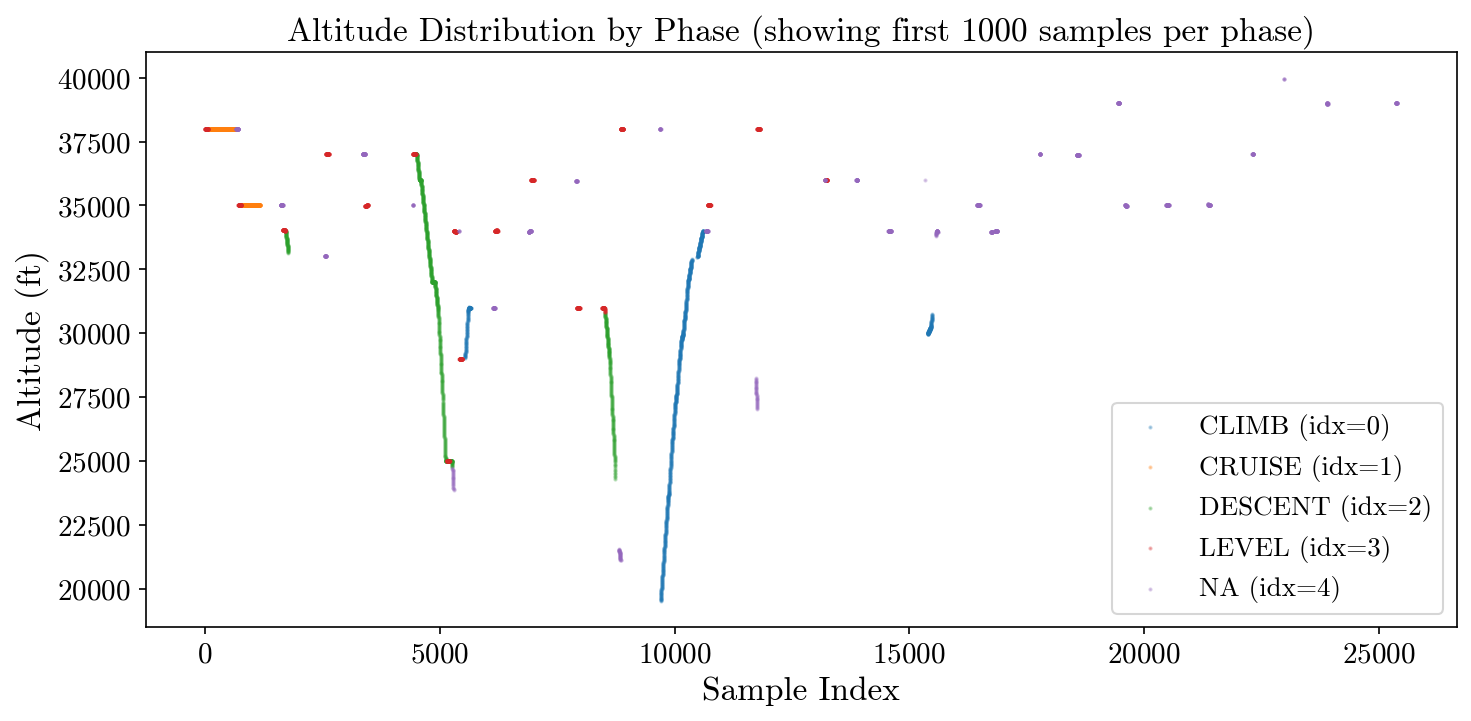


Rows after phase filtering: 98682075


In [5]:
# Map phase strings to integers (for SLDS mode indexing)
phase_mapping = {'CLIMB': 0, 'CRUISE': 1, 'DESCENT': 2, 'LEVEL': 3, 'NA': 4}
slds_df['phase_idx'] = slds_df['phase'].map(phase_mapping)

# Check phase distribution
print(f"\nPhase distribution:")
print(slds_df['phase'].value_counts())
print(f"\nPhase index distribution:")
print(slds_df['phase_idx'].value_counts().sort_index())

# Visualize altitude by phase (sanity check: CLIMB should have higher altitudes than DESCENT over time)
fig, ax = plt.subplots(figsize=(10, 5))
for phase, phase_idx in phase_mapping.items():
    phase_data = slds_df[slds_df['phase'] == phase]
    ax.scatter(phase_data.index[:1000], phase_data['altitude'][:1000], 
               alpha=0.3, s=1, label=f'{phase} (idx={phase_idx})')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Altitude (ft)')
ax.set_title('Altitude Distribution by Phase (showing first 1000 samples per phase)')
ax.legend()
plt.tight_layout()
plt.show()

# Drop rows with missing phase
slds_df = slds_df.dropna(subset=['phase_idx'])
slds_df['phase_idx'] = slds_df['phase_idx'].astype(int)
print(f"\nRows after phase filtering: {len(slds_df)}")

## Cluster Typecodes (Optional: Reduce Mode Count)

**COMMENTED OUT FOR PROOF-OF-CONCEPT**: Using 5 phase-only modes instead of 25 (typecode×phase) modes.

**Reasoning**: 500 flights ÷ 25 modes = only 20 flights/mode → insufficient for stable learning.
With 5 modes: 500 flights ÷ 5 = 100 flights/mode → much better statistics!

**When to uncomment**: If you have 2000+ flights, uncomment this section to use full 25-mode model.

16 typecodes × 5 altitude bins = **80 modes** is still large for SLDS.
Cluster similar aircraft types based on their average dynamics.
**Example**: Group A320/A319/A321 → single "A320 family" cluster.

We have 16 frequent typecodes. Use K-Means clustering on `(mean_groundspeed, mean_acceleration)` to create 5-8 aircraft classes.

In [6]:
# ============================================================================
# TYPECODE CLUSTERING (COMMENTED OUT FOR PROOF-OF-CONCEPT WITH LIMITED DATA)
# ============================================================================
# Uncomment this section if you have 2000+ flights and want full typecode×phase modes
# 
# from sklearn.cluster import KMeans
# 
# # Compute average dynamics per typecode
# typecode_features = slds_df.groupby('typecode')[['groundspeed', 'acceleration', 'turn_rate']].mean()
# print("\nTypecode average dynamics:")
# print(typecode_features)
# 
# # Cluster typecodes into N_CLUSTERS classes
# N_CLUSTERS = 5  # Adjust based on your data (5-8 recommended)
# kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
# typecode_features['cluster'] = kmeans.fit_predict(typecode_features)
# 
# # Map typecodes to clusters
# typecode_to_cluster = typecode_features['cluster'].to_dict()
# slds_df['typecode_cluster'] = slds_df['typecode'].map(typecode_to_cluster)
# 
# print(f"\nTypecode clustering (into {N_CLUSTERS} clusters):")
# print(typecode_features.sort_values('cluster'))
# 
# # Final mode count
# N_phases = len(phase_mapping)
# K_modes = N_CLUSTERS * N_phases
# print(f"\n**Total SLDS modes**: {N_CLUSTERS} typecode clusters × {N_phases} phases = {K_modes} modes")
# print(f"Phase breakdown: {list(phase_mapping.keys())}")

# ============================================================================
# PHASE-ONLY MODES (CURRENT APPROACH FOR PROOF-OF-CONCEPT)
# ============================================================================
print("\n" + "="*70)
print("USING PHASE-ONLY MODES (5 modes total)")
print("="*70)
print("This simplification allows 100 flights/mode instead of 20 flights/mode")
print("Typecode differences still captured by continuous features (groundspeed, etc.)")
print("\nTo use typecode clustering, uncomment the section above and have 2000+ flights\n")

# Set typecode_cluster to 0 for all (single cluster)
N_CLUSTERS = 1
slds_df['typecode_cluster'] = 0

N_phases = len(phase_mapping)
K_modes = N_CLUSTERS * N_phases
print(f"**Total SLDS modes**: {N_CLUSTERS} typecode cluster × {N_phases} phases = {K_modes} modes")
print(f"Phase breakdown: {list(phase_mapping.keys())}")



USING PHASE-ONLY MODES (5 modes total)
This simplification allows 100 flights/mode instead of 20 flights/mode
Typecode differences still captured by continuous features (groundspeed, etc.)

To use typecode clustering, uncomment the section above and have 2000+ flights

**Total SLDS modes**: 1 typecode cluster × 5 phases = 5 modes
Phase breakdown: ['CLIMB', 'CRUISE', 'DESCENT', 'LEVEL', 'NA']
**Total SLDS modes**: 1 typecode cluster × 5 phases = 5 modes
Phase breakdown: ['CLIMB', 'CRUISE', 'DESCENT', 'LEVEL', 'NA']


## Combine Typecode Cluster + Phase → Mode Index

**SLDS requires a single integer mode index** $z_t \in \{0, 1, ..., K-1\}$.

**CURRENT APPROACH (Phase-Only)**:
- `mode = phase_idx` (since N_CLUSTERS=1, typecode_cluster=0)
- Mode 0 = CLIMB, Mode 1 = CRUISE, Mode 2 = DESCENT, Mode 3 = LEVEL, Mode 4 = NA

**FULL APPROACH (Commented Out)**:
- `mode = typecode_cluster * N_phases + phase_idx`
- Example: Cluster 2, CRUISE (phase_idx=1) → Mode = 2×5 + 1 = 11

**This is the discrete latent variable** $z_t$ that switches the dynamics in SLDS!


In [7]:
# Create combined mode index
# Formula: mode = typecode_cluster * N_phases + phase_idx
# With N_CLUSTERS=1: mode = phase_idx
N_phases = len(phase_mapping)  # 5 phases: CLIMB, CRUISE, DESCENT, LEVEL, NA
slds_df['mode'] = slds_df['typecode_cluster'] * N_phases + slds_df['phase_idx']

print("\nMode distribution:")
print(slds_df['mode'].value_counts().sort_index())

# Decode mode to understand what each represents
print("\nMode interpretation (first 15 modes):")
for mode in sorted(slds_df['mode'].unique())[:15]:
    type_cluster = mode // N_phases
    phase_idx = mode % N_phases
    phase_name = list(phase_mapping.keys())[phase_idx]
    count = (slds_df['mode'] == mode).sum()
    print(f"  Mode {mode:2d}: type_cluster={type_cluster}, phase={phase_name:8s} → {count:6d} samples")

# Sanity check: ensure all modes are valid
K_modes = N_CLUSTERS * N_phases
assert slds_df['mode'].min() >= 0
assert slds_df['mode'].max() < K_modes
print(f"\n✓ Mode indices valid: [{slds_df['mode'].min()}, {slds_df['mode'].max()}]")
print(f"✓ Total SLDS modes: {N_CLUSTERS} typecode clusters × {N_phases} phases = {K_modes} modes")



Mode distribution:
mode
0    11356929
1    62780888
2    10873855
3     9805983
4     3864420
Name: count, dtype: int64

Mode interpretation (first 15 modes):
  Mode  0: type_cluster=0, phase=CLIMB    → 11356929 samples
  Mode  1: type_cluster=0, phase=CRUISE   → 62780888 samples
  Mode  0: type_cluster=0, phase=CLIMB    → 11356929 samples
  Mode  1: type_cluster=0, phase=CRUISE   → 62780888 samples
  Mode  2: type_cluster=0, phase=DESCENT  → 10873855 samples
  Mode  3: type_cluster=0, phase=LEVEL    → 9805983 samples
  Mode  2: type_cluster=0, phase=DESCENT  → 10873855 samples
  Mode  3: type_cluster=0, phase=LEVEL    → 9805983 samples
  Mode  4: type_cluster=0, phase=NA       → 3864420 samples
  Mode  4: type_cluster=0, phase=NA       → 3864420 samples

✓ Mode indices valid: [0, 4]
✓ Total SLDS modes: 1 typecode clusters × 5 phases = 5 modes

✓ Mode indices valid: [0, 4]
✓ Total SLDS modes: 1 typecode clusters × 5 phases = 5 modes


## Organize Data by Flight

**SLDS expects**: List of observation sequences `[y_1, y_2, ..., y_N]` where:
- `y_i` is a `(T_i, D_obs)` array for flight `i`
- `T_i` = number of timesteps in flight `i`
- `D_obs` = 4 (`vx`, `vy`, `h_dot`, `altitude`)

**Also track**: Mode sequence `z_i` for each flight (needed for supervised initialization).

In [8]:
# Extract observations and modes per flight
observations = []  # List of (T_i, D_obs) arrays
mode_sequences = []  # List of (T_i,) arrays of mode indices
flight_ids = []  # Track which flight each sequence belongs to

for flight_id, group in tqdm(slds_df.groupby('flight_id'), desc="Organizing flights"):
    group = group.sort_values('timestamp')
    
    # Skip very short flights (need at least 10 timesteps for SLDS)
    if len(group) < 10:
        continue
    
    # Extract observation matrix (T, D_obs): [vx, vy, h_dot, altitude]
    y = group[continuous_features].values.astype(np.float64)
    
    # Extract mode sequence (T,)
    z = group['mode'].values.astype(np.int32)
    
    observations.append(y)
    mode_sequences.append(z)
    flight_ids.append(flight_id)

print(f"\n**Prepared {len(observations)} flights for SLDS training**")
print(f"Total timesteps: {sum(len(y) for y in observations):,}")
print(f"Average flight length: {np.mean([len(y) for y in observations]):.1f} timesteps")
print(f"Observation dimension: {observations[0].shape[1]}")

Organizing flights:   0%|          | 0/141661 [00:00<?, ?it/s]


**Prepared 141661 flights for SLDS training**
Total timesteps: 98,682,075
Average flight length: 696.6 timesteps
Observation dimension: 4


## Feature Normalization with StandardScaler

In [9]:
from sklearn.preprocessing import StandardScaler
import pickle

# Concatenate all observations to fit scaler on full dataset
all_obs_concat = np.concatenate(observations, axis=0)
print(f"Total observations for scaler fitting: {all_obs_concat.shape[0]:,} timesteps")

# Print pre-scaling statistics
print("\n**Pre-Scaling Statistics** (raw features):")
print("=" * 80)
for i, name in enumerate(continuous_features):
    vals = all_obs_concat[:, i]
    print(f"{name:20s}: mean={np.mean(vals):12.3f}, std={np.std(vals):12.3f}, "
          f"min={np.min(vals):12.3f}, max={np.max(vals):12.3f}")

# Fit StandardScaler (mean=0, std=1)
scaler = StandardScaler()
scaler.fit(all_obs_concat)

print(f"\n✓ StandardScaler fitted (mean=0, std=1)")
print(f"  Feature means: {scaler.mean_}")
print(f"  Feature stds:  {scaler.scale_}")

# Transform each flight's observations
observations_scaled = []
for y in tqdm(observations, desc="Scaling observations"):
    y_scaled = scaler.transform(y)
    observations_scaled.append(y_scaled)

# Verify scaling worked (mean ≈ 0, std ≈ 1)
all_obs_scaled = np.concatenate(observations_scaled, axis=0)
print("\n**Post-Scaling Statistics** (Standardized):")
print("=" * 80)
for i, name in enumerate(continuous_features):
    vals = all_obs_scaled[:, i]
    print(f"{name:20s}: mean={np.mean(vals):12.6f}, std={np.std(vals):12.6f}, "
          f"min={np.min(vals):12.6f}, max={np.max(vals):12.6f}")

# Replace original observations with scaled ones
observations = observations_scaled

# Save scaler to disk for inverse transform during sampling
scaler_path = "/store/fusg/VT2/slds/feature_scaler_v2.pkl"
os.makedirs(os.path.dirname(scaler_path), exist_ok=True)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"\n✓ StandardScaler saved to: {scaler_path}")

Total observations for scaler fitting: 98,682,075 timesteps

**Pre-Scaling Statistics** (raw features):
vx                  : mean=       3.249, std=     151.294, min=   -1231.608, max=     979.498
vx                  : mean=       3.249, std=     151.294, min=   -1231.608, max=     979.498
vy                  : mean=      -0.257, std=     169.623, min=   -1032.032, max=    1831.415
vy                  : mean=      -0.257, std=     169.623, min=   -1032.032, max=    1831.415
vertical_rate       : mean=       0.097, std=       3.429, min=    -149.555, max=     162.235
vertical_rate       : mean=       0.097, std=       3.429, min=    -149.555, max=     162.235
altitude            : mean=   33824.518, std=    4795.724, min=   19500.001, max=   45000.001
altitude            : mean=   33824.518, std=    4795.724, min=   19500.001, max=   45000.001

✓ StandardScaler fitted (mean=0, std=1)
  Feature means: [ 3.24887896e+00 -2.57110135e-01  9.67581692e-02  3.38245179e+04]
  Feature stds:  [1.

Scaling observations:   0%|          | 0/141661 [00:00<?, ?it/s]


**Post-Scaling Statistics** (Standardized):
vx                  : mean=    0.000000, std=    1.000000, min=   -8.161956, max=    6.452654
vx                  : mean=    0.000000, std=    1.000000, min=   -8.161956, max=    6.452654
vy                  : mean=   -0.000000, std=    1.000000, min=   -6.082752, max=   10.798488
vy                  : mean=   -0.000000, std=    1.000000, min=   -6.082752, max=   10.798488
vertical_rate       : mean=    0.000000, std=    1.000000, min=  -43.637825, max=   47.278733
vertical_rate       : mean=    0.000000, std=    1.000000, min=  -43.637825, max=   47.278733
altitude            : mean=    0.000000, std=    1.000000, min=   -2.986935, max=    2.330302

✓ StandardScaler saved to: /store/fusg/VT2/slds/feature_scaler_v2.pkl
altitude            : mean=    0.000000, std=    1.000000, min=   -2.986935, max=    2.330302

✓ StandardScaler saved to: /store/fusg/VT2/slds/feature_scaler_v2.pkl


## Data Statistics and Visualization


Continuous Feature Statistics:
vx (m/s)                 : mean=    0.000, std=    1.000, min=   -8.162, max=    6.453
vx (m/s)                 : mean=    0.000, std=    1.000, min=   -8.162, max=    6.453
vy (m/s)                 : mean=   -0.000, std=    1.000, min=   -6.083, max=   10.798
vy (m/s)                 : mean=   -0.000, std=    1.000, min=   -6.083, max=   10.798
Vertical Rate (m/s)      : mean=    0.000, std=    1.000, min=  -43.638, max=   47.279
Vertical Rate (m/s)      : mean=    0.000, std=    1.000, min=  -43.638, max=   47.279
Altitude (ft)            : mean=    0.000, std=    1.000, min=   -2.987, max=    2.330
Altitude (ft)            : mean=    0.000, std=    1.000, min=   -2.987, max=    2.330


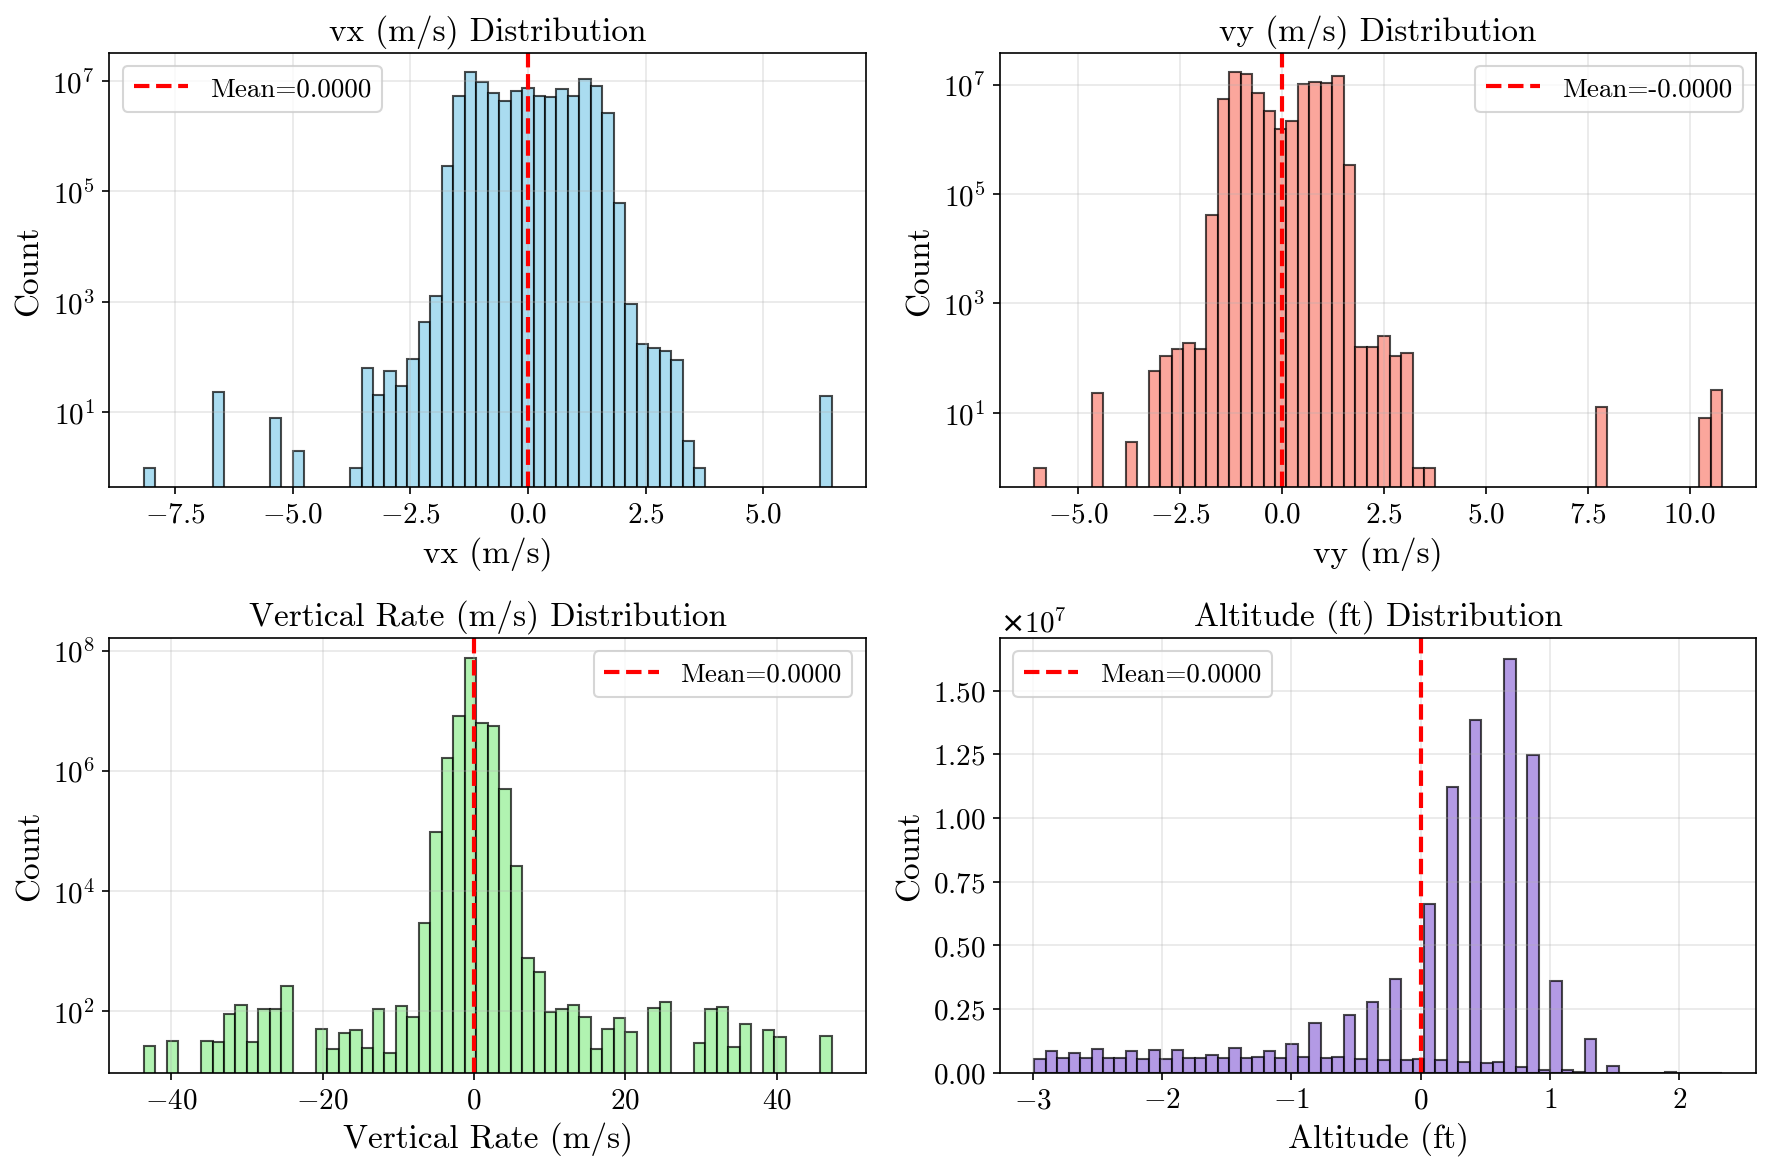

In [10]:
# Flatten all observations for statistics
all_obs = np.concatenate(observations, axis=0)

# Print statistics (NOW 4D)
feature_names = ['vx (m/s)', 'vy (m/s)', 'Vertical Rate (m/s)', 'Altitude (ft)']
print("\nContinuous Feature Statistics:")
print("=" * 70)
for i, name in enumerate(feature_names):
    vals = all_obs[:, i]
    print(f"{name:25s}: mean={np.mean(vals):9.3f}, std={np.std(vals):9.3f}, "
          f"min={np.min(vals):9.3f}, max={np.max(vals):9.3f}")

# Plot distributions (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
colors = ['skyblue', 'salmon', 'lightgreen', 'mediumpurple']

for i, (name, ax) in enumerate(zip(feature_names, axes)):
    vals = all_obs[:, i]
    ax.hist(vals, bins=60, alpha=0.7, edgecolor='black', color=colors[i])
    ax.set_xlabel(name)
    ax.set_ylabel('Count')
    ax.set_title(f'{name} Distribution')
    ax.grid(True, alpha=0.3)

    if i in [0, 1, 2]:
        ax.set_yscale('log')

    # Add mean line
    ax.axvline(np.mean(vals), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(vals):.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

## Save Prepared Data

**Output**: Pickle file containing:
1. `observations`: List of (T_i, 5) STANDARDIZED observation arrays (StandardScaler → mean=0, std=1)
2. `mode_sequences`: List of (T_i,) mode index arrays
3. `flight_ids`: List of flight IDs
4. `metadata`: Dictionary with:
   - `K_modes`: Total number of modes (typecode_clusters × 5 phases)
   - `D_obs`: Observation dimension (5: v, v_dot, psi_dot, h_dot, altitude)
   - `feature_names`: List of feature names
   - `typecode_to_cluster`: Mapping from typecode to cluster
   - `phase_mapping`: CLIMB/CRUISE/DESCENT/LEVEL/NA → 0/1/2/3/4
   - `scaler_path`: Path to StandardScaler pickle for inverse transform
   - `features_are_scaled`: True (features standardized to mean=0, std=1)

In [11]:
# Package data for SLDS training
slds_data = {
    'observations': observations,  # STANDARDIZED with StandardScaler (mean=0, std=1)
    'mode_sequences': mode_sequences,
    'flight_ids': flight_ids,
    'metadata': {
        'K_modes': K_modes,
        'D_obs': 4,  # 4D (vx, vy, h_dot, altitude)
        'D_latent': 4,  # latent dim = obs dim (identity observation model)
        'feature_names': continuous_features,  # ['vx','vy','vertical_rate','altitude']
        'typecode_to_cluster': {},  # phase-only model (all typecodes → cluster 0)
        'phase_mapping': phase_mapping,
        'N_phases': N_phases,
        'N_typecode_clusters': N_CLUSTERS,
        'frequent_types': frequent_types,
        'scaler_path': scaler_path,  # StandardScaler for inverse transform
        'features_are_scaled': True
    }
}

# Save to disk
output_path = "/store/fusg/VT2/slds/slds_data_prepared_v2.pkl"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'wb') as f:
    pickle.dump(slds_data, f)

print(f"\nSLDS data saved to: {output_path}")
print(f"  - {len(observations)} flights")
print(f"  - {K_modes} modes ({N_CLUSTERS} typecode clusters × {N_phases} phases)")
print(f"  - {sum(len(y) for y in observations):,} total timesteps")
print(f"  - Observation dimension: {slds_data['metadata']['D_obs']} (continuous, STANDARDIZED)")
print(f"  - Feature scaler: {scaler_path} (StandardScaler)")


SLDS data saved to: /store/fusg/VT2/slds/slds_data_prepared_v2.pkl
  - 141661 flights
  - 5 modes (1 typecode clusters × 5 phases)
  - 98,682,075 total timesteps
  - Observation dimension: 4 (continuous, STANDARDIZED)
  - Feature scaler: /store/fusg/VT2/slds/feature_scaler_v2.pkl (StandardScaler)
  - 98,682,075 total timesteps
  - Observation dimension: 4 (continuous, STANDARDIZED)
  - Feature scaler: /store/fusg/VT2/slds/feature_scaler_v2.pkl (StandardScaler)
